# Top 10 Variables Correlation Analysis with PHQ-9 Outcomes

This notebook focuses on identifying and visualizing the top 10 variables that correlate most with PHQ-9 `total_score` and `depression_severity` as outcome variables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10


## Load and Prepare Data


In [2]:
# Load EMA data files
mood_df = pd.read_csv("EMA/Mood.csv")
stress_df = pd.read_csv("EMA/Stress.csv")
sleep_df = pd.read_csv("EMA/Sleep.csv")
exercise_df = pd.read_csv("EMA/Exercise.csv")
social_df = pd.read_csv("EMA/Social.csv")
behavior_df = pd.read_csv("EMA/Behavior.csv")

# Load static data - only use total_score and depression_severity from PHQ-9
phq9_df = pd.read_csv("static/clean_PHQ-9.csv")
grades_df = pd.read_csv("static/grades.csv")

print("Data loaded successfully!")


Data loaded successfully!


## Aggregate Data by User


In [3]:
# Function to aggregate numeric columns by user_id
def aggregate_by_user(df, user_col="user_id", agg_method="mean"):
    """Aggregate numeric columns by user_id"""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if user_col in numeric_cols:
        numeric_cols.remove(user_col)

    if len(numeric_cols) == 0:
        return pd.DataFrame()

    if agg_method == "mean":
        aggregated = df.groupby(user_col)[numeric_cols].mean().reset_index()
    elif agg_method == "median":
        aggregated = df.groupby(user_col)[numeric_cols].median().reset_index()
    else:
        aggregated = df.groupby(user_col)[numeric_cols].agg(agg_method).reset_index()

    return aggregated


# Aggregate each dataset
mood_agg = aggregate_by_user(mood_df, "user_id", "mean")
stress_agg = aggregate_by_user(stress_df, "user_id", "mean")
sleep_agg = aggregate_by_user(sleep_df, "user_id", "mean")
exercise_agg = aggregate_by_user(exercise_df, "user_id", "mean")
social_agg = aggregate_by_user(social_df, "user_id", "mean")
behavior_agg = aggregate_by_user(behavior_df, "user_id", "mean")

# Prepare PHQ-9 data - ONLY use total_score and depression_severity
# First, convert depression_severity to numeric for correlation
phq9_severity_map = {
    "": 0,
    "Minimal depression": 1,
    "Mild depression": 2,
    "Moderate depression": 3,
    "Moderately severe depression": 4,
    "Severe depression": 5,
}
phq9_df["depression_severity_numeric"] = phq9_df["depression_severity"].map(phq9_severity_map)

# Aggregate PHQ-9 - only keep total_score and depression_severity_numeric
phq9_agg = (
    phq9_df.groupby("uid")[["total_score", "depression_severity_numeric"]].mean().reset_index()
)
phq9_agg = phq9_agg.rename(columns={"uid": "user_id"})

# Prepare grades data
grades_agg = grades_df.rename(columns={"uid": "user_id"})

print("Data aggregated successfully!")


Data aggregated successfully!


## Merge All Data


In [4]:
# Merge all datasets on user_id
merged_df = mood_agg.copy()

# Add prefix to column names to avoid conflicts
datasets = {
    "stress": (stress_agg, "stress_"),
    "sleep": (sleep_agg, "sleep_"),
    "exercise": (exercise_agg, "exercise_"),
    "social": (social_agg, "social_"),
    "behavior": (behavior_agg, "behavior_"),
    "phq9": (phq9_agg, "phq9_"),
    "grades": (grades_agg, "grades_"),
}

for name, (df, prefix) in datasets.items():
    if not df.empty:
        df_prefixed = df.copy()
        # Don't prefix user_id
        cols_to_prefix = [col for col in df_prefixed.columns if col != "user_id"]
        df_prefixed = df_prefixed.rename(columns={col: prefix + col for col in cols_to_prefix})
        merged_df = pd.merge(merged_df, df_prefixed, on="user_id", how="outer")

# Also add mood prefix for consistency
mood_cols = [
    col
    for col in merged_df.columns
    if col not in ["user_id"]
    and not col.startswith(
        ("stress_", "sleep_", "exercise_", "social_", "behavior_", "phq9_", "grades_")
    )
]
merged_df = merged_df.rename(columns={col: "mood_" + col for col in mood_cols if col != "user_id"})

print(f"Merged dataset shape: {merged_df.shape}")
print(f"\nOutcome variables: phq9_total_score, phq9_depression_severity_numeric")


Merged dataset shape: (49, 38)

Outcome variables: phq9_total_score, phq9_depression_severity_numeric


## Calculate Correlations and Identify Top 10 Variables


In [5]:
# Select only numeric columns for correlation
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
corr_df = merged_df[numeric_cols]

# Calculate correlation matrix
correlation_matrix = corr_df.corr()

# Define outcome variables
outcome_vars = ["phq9_total_score", "phq9_depression_severity_numeric"]

# Get correlations with outcome variables
outcome_correlations = {}
for outcome in outcome_vars:
    if outcome in correlation_matrix.index:
        # Get absolute correlations, exclude the outcome variable itself and other outcome variables
        other_vars = [v for v in correlation_matrix.index if v not in outcome_vars]
        corr_with_outcome = (
            correlation_matrix.loc[outcome, other_vars].abs().sort_values(ascending=False)
        )
        outcome_correlations[outcome] = corr_with_outcome

# Get top 10 variables for each outcome
top10_vars_per_outcome = {}
for outcome, corrs in outcome_correlations.items():
    top10_vars_per_outcome[outcome] = corrs.head(10).index.tolist()

# Combine to get unique top variables (prioritize by highest correlation)
all_top_vars = []
seen_vars = set()
for outcome in outcome_vars:
    if outcome in top10_vars_per_outcome:
        for var in top10_vars_per_outcome[outcome]:
            if var not in seen_vars:
                all_top_vars.append(var)
                seen_vars.add(var)
                if len(all_top_vars) >= 10:
                    break
    if len(all_top_vars) >= 10:
        break

# If we don't have 10 yet, add more from the other outcome
if len(all_top_vars) < 10:
    for outcome in outcome_vars:
        if outcome in top10_vars_per_outcome:
            for var in top10_vars_per_outcome[outcome]:
                if var not in seen_vars:
                    all_top_vars.append(var)
                    seen_vars.add(var)
                    if len(all_top_vars) >= 10:
                        break
                if len(all_top_vars) >= 10:
                    break

top10_vars = all_top_vars[:10]

print(f"Top 10 variables identified: {len(top10_vars)}")
print("\nTop 10 variables:")
for i, var in enumerate(top10_vars, 1):
    print(f"  {i}. {var}")


Top 10 variables identified: 10

Top 10 variables:
  1. mood_sad
  2. mood_sadornot
  3. grades_gpa all
  4. sleep_sleep_hours
  5. behavior_anxious
  6. sleep_sleep_quality
  7. grades_gpa 13s
  8. sleep_sleepiness
  9. behavior_sympathetic
  10. mood_happyornot


## Create Readable Variable Names


In [6]:
# Create readable variable name mapping
def create_readable_names(col_name):
    """Convert variable names to more readable format"""
    name = col_name

    # Outcome variables
    if name == "phq9_total_score":
        return "PHQ-9: Total Score"
    elif name == "phq9_depression_severity_numeric":
        return "PHQ-9: Depression Severity"

    # Remove prefixes and format
    if name.startswith("mood_"):
        base = name.replace("mood_", "")
        if base == "happy":
            return "Mood: Happy"
        elif base == "happyornot":
            return "Mood: Happy (Binary)"
        elif base == "sad":
            return "Mood: Sad"
        elif base == "sadornot":
            return "Mood: Sad (Binary)"
        elif base == "resp_time":
            return "Mood: Response Time"
        else:
            return f"Mood: {base.title()}"

    elif name.startswith("stress_"):
        base = name.replace("stress_", "")
        if base == "level":
            return "Stress: Level"
        elif base == "resp_time":
            return "Stress: Response Time"
        else:
            return f"Stress: {base.title()}"

    elif name.startswith("sleep_"):
        base = name.replace("sleep_", "")
        if base == "sleep_hours":
            return "Sleep: Hours"
        elif base == "sleep_quality":
            return "Sleep: Quality"
        elif base == "sleepiness":
            return "Sleep: Sleepiness"
        elif base == "resp_time":
            return "Sleep: Response Time"
        else:
            return f"Sleep: {base.title()}"

    elif name.startswith("exercise_"):
        base = name.replace("exercise_", "")
        if base == "exercise":
            return "Exercise: Level"
        elif base == "walk":
            return "Exercise: Walk"
        elif base == "have":
            return "Exercise: Have"
        elif base == "schedule":
            return "Exercise: Scheduled"
        elif base == "hour":
            return "Exercise: Hour"
        elif base == "latitude":
            return "Exercise: Latitude"
        elif base == "longitude":
            return "Exercise: Longitude"
        elif base == "has_location":
            return "Exercise: Has Location"
        elif base == "resp_time":
            return "Exercise: Response Time"
        else:
            return f"Exercise: {base.title()}"

    elif name.startswith("social_"):
        base = name.replace("social_", "")
        if base == "number":
            return "Social: Number"
        elif base == "resp_time":
            return "Social: Response Time"
        else:
            return f"Social: {base.title()}"

    elif name.startswith("behavior_"):
        base = name.replace("behavior_", "")
        if base == "anxious":
            return "Behavior: Anxious"
        elif base == "calm":
            return "Behavior: Calm"
        elif base == "conventional":
            return "Behavior: Conventional"
        elif base == "critical":
            return "Behavior: Critical"
        elif base == "dependable":
            return "Behavior: Dependable"
        elif base == "disorganized":
            return "Behavior: Disorganized"
        elif base == "enthusiastic":
            return "Behavior: Enthusiastic"
        elif base == "experiences":
            return "Behavior: Experiences"
        elif base == "reserved":
            return "Behavior: Reserved"
        elif base == "sympathetic":
            return "Behavior: Sympathetic"
        elif base == "resp_time":
            return "Behavior: Response Time"
        else:
            return f"Behavior: {base.title()}"

    elif name.startswith("grades_"):
        base = name.replace("grades_", "")
        if base == "gpa all":
            return "GPA: Overall"
        elif base == "gpa 13s":
            return "GPA: 13s"
        elif base == "cs 65":
            return "Grade: CS 65"
        else:
            return f"Grade: {base.title()}"

    else:
        return name.title()


# Create readable name mapping for all variables
all_vars = top10_vars + outcome_vars
readable_names = {col: create_readable_names(col) for col in all_vars}

print("Readable names created!")
for orig, readable in readable_names.items():
    print(f"  {orig} → {readable}")


Readable names created!
  mood_sad → Mood: Sad
  mood_sadornot → Mood: Sad (Binary)
  grades_gpa all → GPA: Overall
  sleep_sleep_hours → Sleep: Hours
  behavior_anxious → Behavior: Anxious
  sleep_sleep_quality → Sleep: Quality
  grades_gpa 13s → GPA: 13s
  sleep_sleepiness → Sleep: Sleepiness
  behavior_sympathetic → Behavior: Sympathetic
  mood_happyornot → Mood: Happy (Binary)
  phq9_total_score → PHQ-9: Total Score
  phq9_depression_severity_numeric → PHQ-9: Depression Severity


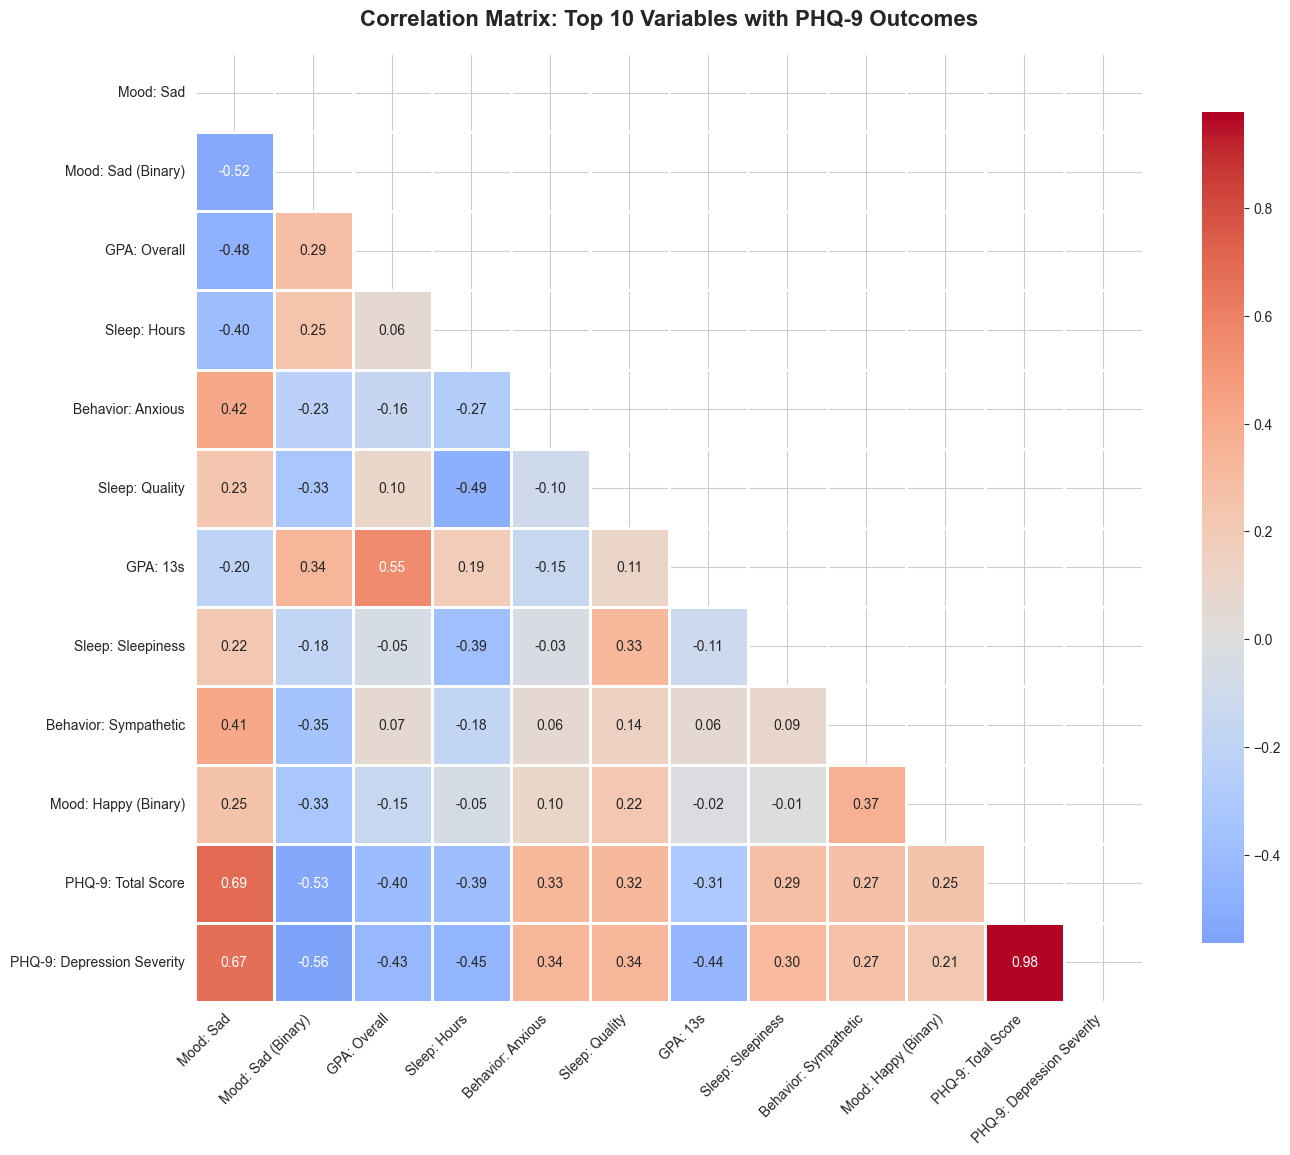

In [7]:
# Create correlation matrix for top 10 + outcomes
vars_for_heatmap = top10_vars + outcome_vars
corr_subset = correlation_matrix.loc[vars_for_heatmap, vars_for_heatmap]

# Convert to readable names
corr_subset_readable = corr_subset.copy()
corr_subset_readable.columns = [
    readable_names.get(col, col) for col in corr_subset_readable.columns
]
corr_subset_readable.index = [readable_names.get(idx, idx) for idx in corr_subset_readable.index]

# Create heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_subset_readable, dtype=bool))  # Mask upper triangle
sns.heatmap(
    corr_subset_readable,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    xticklabels=True,
    yticklabels=True,
)
plt.title(
    "Correlation Matrix: Top 10 Variables with PHQ-9 Outcomes",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("top10_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## Visualization 2: Bar Chart - Top 10 Correlations with Each Outcome


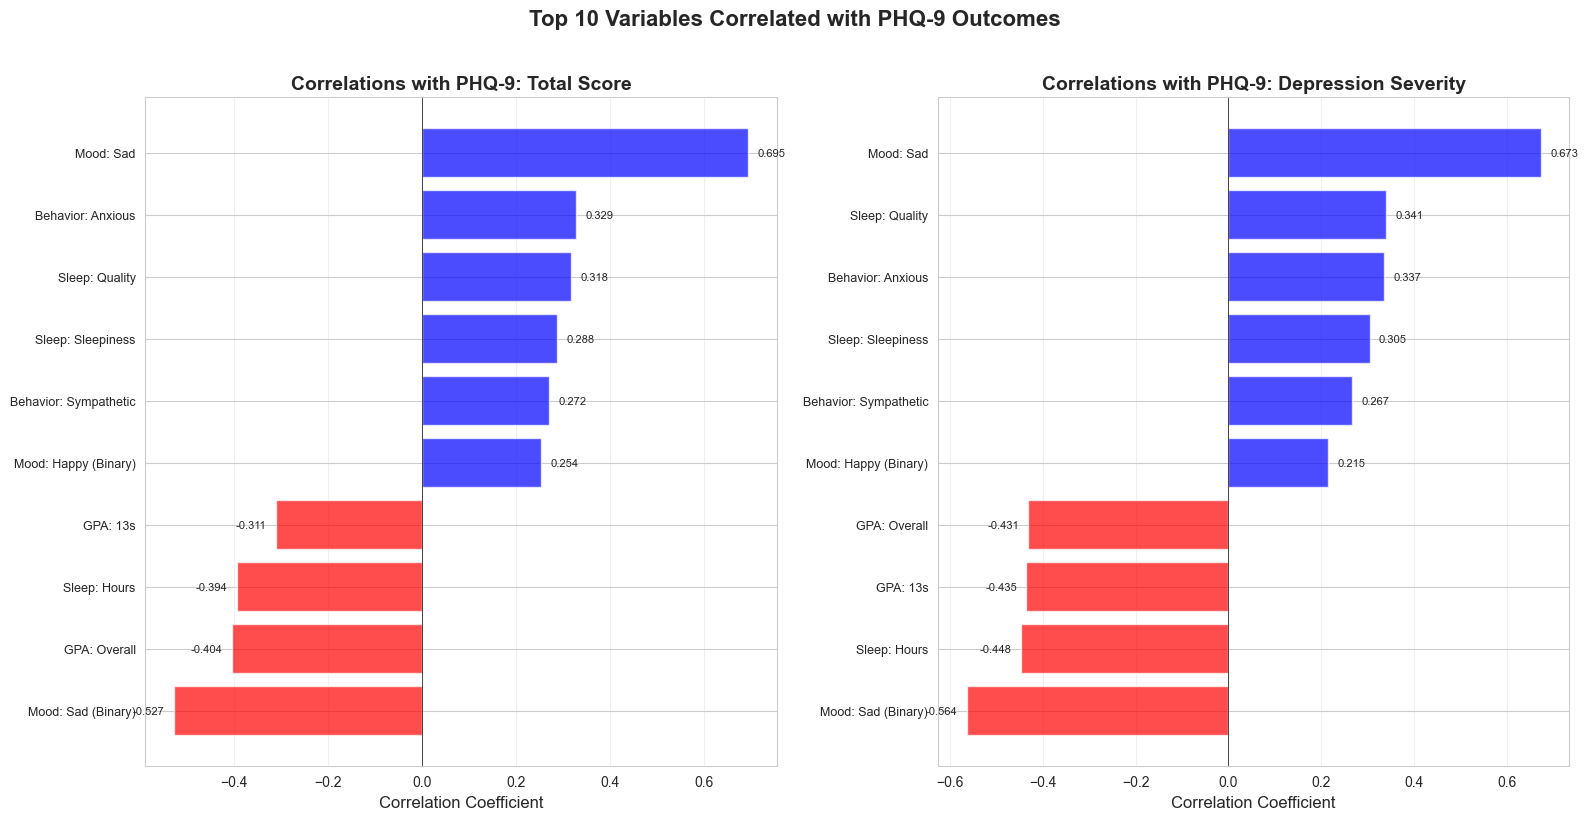

In [8]:
# Create bar charts for each outcome variable
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

outcome_readable = {
    "phq9_total_score": "PHQ-9: Total Score",
    "phq9_depression_severity_numeric": "PHQ-9: Depression Severity",
}

for idx, outcome in enumerate(outcome_vars):
    if outcome in correlation_matrix.index:
        # Get correlations with top 10 variables
        corr_with_top10 = correlation_matrix.loc[outcome, top10_vars].sort_values(ascending=True)

        # Convert to readable names
        corr_readable = pd.Series(
            corr_with_top10.values, index=[readable_names.get(v, v) for v in corr_with_top10.index]
        )

        # Create bar chart
        colors = ["red" if x < 0 else "blue" for x in corr_readable.values]
        axes[idx].barh(range(len(corr_readable)), corr_readable.values, color=colors, alpha=0.7)
        axes[idx].set_yticks(range(len(corr_readable)))
        axes[idx].set_yticklabels(corr_readable.index, fontsize=9)
        axes[idx].set_xlabel("Correlation Coefficient", fontsize=12)
        axes[idx].set_title(
            f"Correlations with {outcome_readable[outcome]}", fontsize=14, fontweight="bold"
        )
        axes[idx].axvline(x=0, color="black", linestyle="-", linewidth=0.5)
        axes[idx].grid(axis="x", alpha=0.3)

        # Add correlation values as text
        for i, (var, corr_val) in enumerate(corr_readable.items()):
            axes[idx].text(
                corr_val + (0.02 if corr_val >= 0 else -0.02),
                i,
                f"{corr_val:.3f}",
                va="center",
                ha="left" if corr_val >= 0 else "right",
                fontsize=8,
            )

plt.suptitle(
    "Top 10 Variables Correlated with PHQ-9 Outcomes", fontsize=16, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("top10_correlations_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()


## Visualization 3: Combined Correlation Heatmap - Outcomes vs Top 10


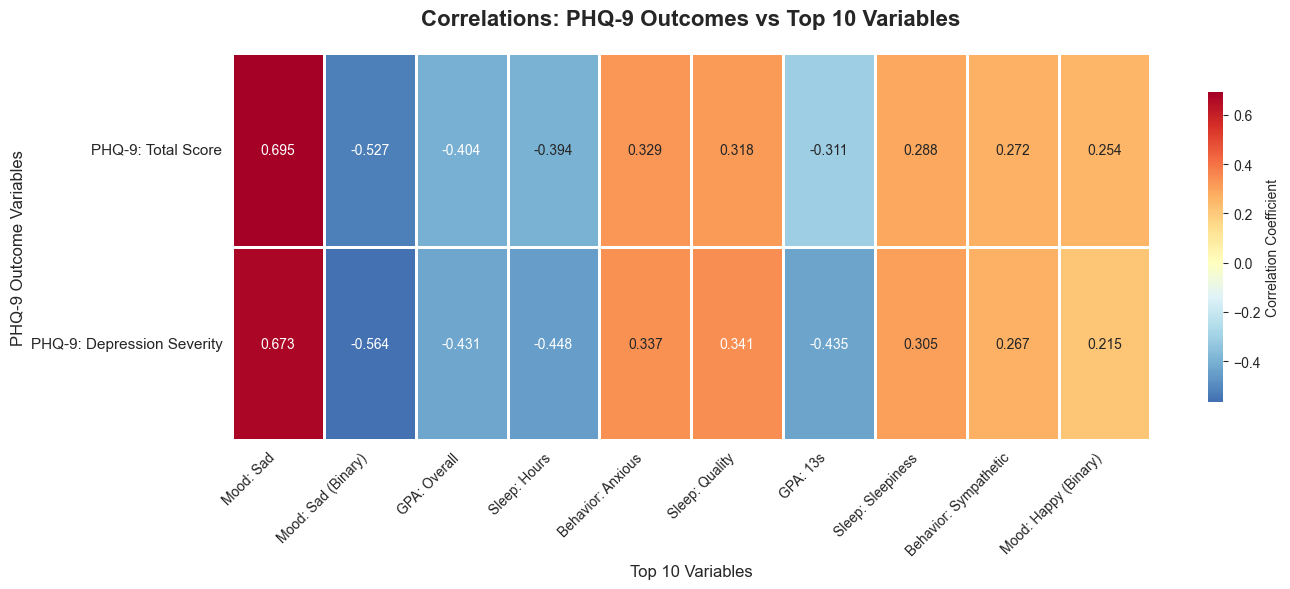

In [9]:
# Create a focused heatmap showing only correlations between outcomes and top 10 variables
outcome_top10_corr = correlation_matrix.loc[outcome_vars, top10_vars]

# Convert to readable names
outcome_top10_corr_readable = outcome_top10_corr.copy()
outcome_top10_corr_readable.columns = [
    readable_names.get(col, col) for col in outcome_top10_corr_readable.columns
]
outcome_top10_corr_readable.index = [
    readable_names.get(idx, idx) for idx in outcome_top10_corr_readable.index
]

plt.figure(figsize=(14, 6))
sns.heatmap(
    outcome_top10_corr_readable,
    annot=True,
    fmt=".3f",
    cmap="RdYlBu_r",
    center=0,
    square=False,
    linewidths=1,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
)
plt.title(
    "Correlations: PHQ-9 Outcomes vs Top 10 Variables", fontsize=16, fontweight="bold", pad=20
)
plt.xlabel("Top 10 Variables", fontsize=12)
plt.ylabel("PHQ-9 Outcome Variables", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig("top10_outcomes_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## Summary Statistics


In [10]:
print("=== TOP 10 VARIABLES CORRELATION ANALYSIS SUMMARY ===\n")
print(f"Total number of variables analyzed: {len(numeric_cols)}")
print(f"Number of observations: {len(merged_df)}")
print(f"\nOutcome variables:")
for outcome in outcome_vars:
    print(f"  - {readable_names.get(outcome, outcome)}")

print(f"\n=== TOP 10 VARIABLES (by correlation with outcomes) ===")
for i, var in enumerate(top10_vars, 1):
    readable = readable_names.get(var, var)
    print(f"\n{i}. {readable}")
    for outcome in outcome_vars:
        if outcome in correlation_matrix.index and var in correlation_matrix.columns:
            corr_val = correlation_matrix.loc[outcome, var]
            outcome_name = readable_names.get(outcome, outcome)
            print(f"   → {outcome_name}: {corr_val:.3f}")

print("\n=== STRONGEST CORRELATIONS ===")
for outcome in outcome_vars:
    if outcome in top10_vars_per_outcome:
        print(f"\n{readable_names.get(outcome, outcome)}:")
        top_vars = top10_vars_per_outcome[outcome]
        for i, var in enumerate(top_vars[:5], 1):  # Show top 5
            corr_val = correlation_matrix.loc[outcome, var]
            readable = readable_names.get(var, var)
            print(f"  {i}. {readable}: {corr_val:.3f}")


=== TOP 10 VARIABLES CORRELATION ANALYSIS SUMMARY ===

Total number of variables analyzed: 37
Number of observations: 49

Outcome variables:
  - PHQ-9: Total Score
  - PHQ-9: Depression Severity

=== TOP 10 VARIABLES (by correlation with outcomes) ===

1. Mood: Sad
   → PHQ-9: Total Score: 0.695
   → PHQ-9: Depression Severity: 0.673

2. Mood: Sad (Binary)
   → PHQ-9: Total Score: -0.527
   → PHQ-9: Depression Severity: -0.564

3. GPA: Overall
   → PHQ-9: Total Score: -0.404
   → PHQ-9: Depression Severity: -0.431

4. Sleep: Hours
   → PHQ-9: Total Score: -0.394
   → PHQ-9: Depression Severity: -0.448

5. Behavior: Anxious
   → PHQ-9: Total Score: 0.329
   → PHQ-9: Depression Severity: 0.337

6. Sleep: Quality
   → PHQ-9: Total Score: 0.318
   → PHQ-9: Depression Severity: 0.341

7. GPA: 13s
   → PHQ-9: Total Score: -0.311
   → PHQ-9: Depression Severity: -0.435

8. Sleep: Sleepiness
   → PHQ-9: Total Score: 0.288
   → PHQ-9: Depression Severity: 0.305

9. Behavior: Sympathetic
   → PH